# Customer Churn Prediction and Analysis

## Exploratory Data Analysis (EDA)

### Objective

The objective of this notebook is to explore the cleaned dataset, identify patterns, discover relationships between variables, and generate business insights that explain customer churn behavior.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

plt.style.use("ggplot")

In [2]:
df = pd.read_csv("../data/cleaned/customer_churn_cleaned.csv")

# Dataset Overview

Before starting the exploratory analysis, we first review the overall structure of the cleaned dataset.

In [3]:
print("="*50)
print("DATASET OVERVIEW")
print("="*50)

print(f"Rows      : {df.shape[0]}")
print(f"Columns   : {df.shape[1]}")

print("\nData Types")

display(df.dtypes.value_counts())

print("\nMissing Values")

display(df.isnull().sum())

print("\nDuplicate Rows")

print(df.duplicated().sum())

DATASET OVERVIEW
Rows      : 7032
Columns   : 21

Data Types


str        17
int64       2
float64     2
Name: count, dtype: int64


Missing Values


customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


Duplicate Rows
0


# Section 2: Target Variable Analysis

## Business Question

What is the distribution of customer churn?

Understanding the balance between customers who stayed and customers who left the company is the first step before building any predictive model.

In [4]:
# Churn Count

churn_counts = df["Churn"].value_counts()

display(churn_counts)

Churn
No     5163
Yes    1869
Name: count, dtype: int64

In [5]:
# Churn Percentage

churn_percentage = (
    df["Churn"]
      .value_counts(normalize=True)
      .mul(100)
      .round(2)
)

display(churn_percentage)

Churn
No     73.42
Yes    26.58
Name: proportion, dtype: float64

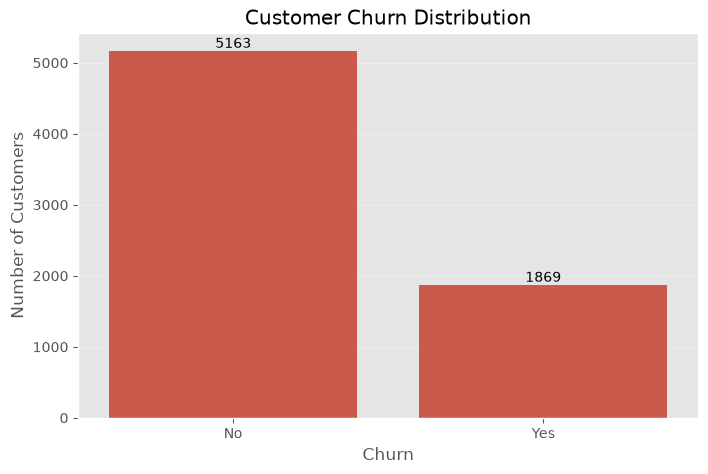

In [11]:
plt.figure(figsize=(8,5))
ax = sns.countplot(
    data=df,
    x="Churn"
)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.grid(axis="y", alpha=0.3)

for container in ax.containers:
    ax.bar_label(container)

plt.show()

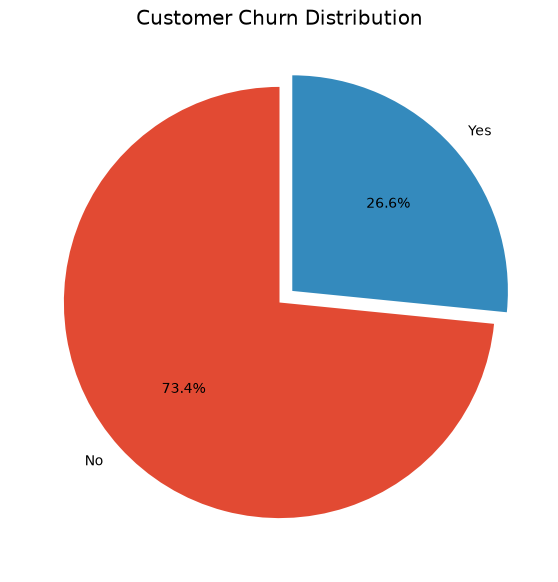

In [10]:
plt.figure(figsize=(7,7))

plt.pie(
    churn_counts,
    labels=churn_counts.index,
    autopct="%1.1f%%",
    startangle=90,
    explode=[0,0.08]
)

plt.title("Customer Churn Distribution")

plt.show()

## Insight

- The dataset is imbalanced, with **73.4%** of customers remaining with the company and **26.6%** having churned.
- Although the majority of customers stayed, more than one-quarter of the customer base has left the company.
- This imbalance should be considered during model development, as relying solely on accuracy may produce misleading results.

## Business Recommendation

The company should focus on identifying the characteristics of the 26.6% churned customers and develop targeted retention strategies to reduce customer loss.

During model development, evaluation metrics such as Precision, Recall, F1-score, and ROC-AUC should be prioritized alongside Accuracy due to the class imbalance.

In [24]:
target_summary = pd.DataFrame({

    "Metric":[
        "Customers Stayed",
        "Customers Churned",
        "Churn Rate",
        "Class Balance"
    ],

    "Result":[
        5163,
        1869,
        "26.6%",
        "Imbalanced"
    ],

    "Business Impact":[
        "Majority Class",
        "Minority Class",
        "Requires Attention",
        "Consider during Modeling"
    ]

})

target_summary

,Metric,Result,Business Impact
0,Customers Stayed,5163,Majority Class
1,Customers Churned,1869,Minority Class
2,Churn Rate,26.6%,Requires Attention
3,Class Balance,Imbalanced,Consider during Modeling


### Target Analysis Summary

The dataset exhibits class imbalance, with approximately one-quarter of customers having churned. This imbalance should be considered during model development by using appropriate evaluation metrics and, if necessary, imbalance-handling techniques.

# Section 3: Demographic Analysis

## Business Question

Do customer demographic characteristics influence customer churn?

This section investigates whether demographic factors such as gender, senior citizen status, partner status, and dependents are associated with customer churn.

In [19]:
def plot_churn_by_feature(feature, title):
    """
    Plot customer churn distribution for a categorical feature.
    """

    plt.figure(figsize=(8,5))

    ax = sns.countplot(
        data=df,
        x=feature,
        hue="Churn"
    )

    plt.title(title, fontsize=14, fontweight="bold")
    plt.xlabel(feature)
    plt.ylabel("Customer Count")

    for container in ax.containers:
        ax.bar_label(container)

    plt.grid(axis="y", alpha=0.3)

    plt.show()

    display(
        pd.crosstab(
            df[feature],
            df["Churn"],
            normalize="index"
        ).round(3) * 100
    )

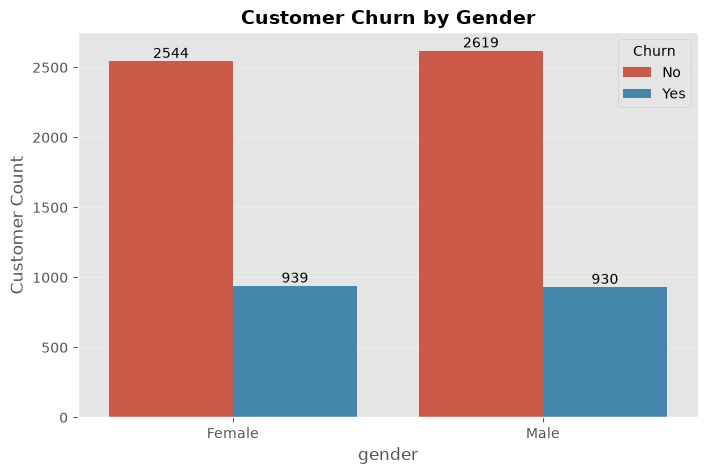

Churn,No,Yes
gender,,
Female,73.0,27.0
Male,73.8,26.2


In [20]:
plot_churn_by_feature(
    "gender",
    "Customer Churn by Gender"
)

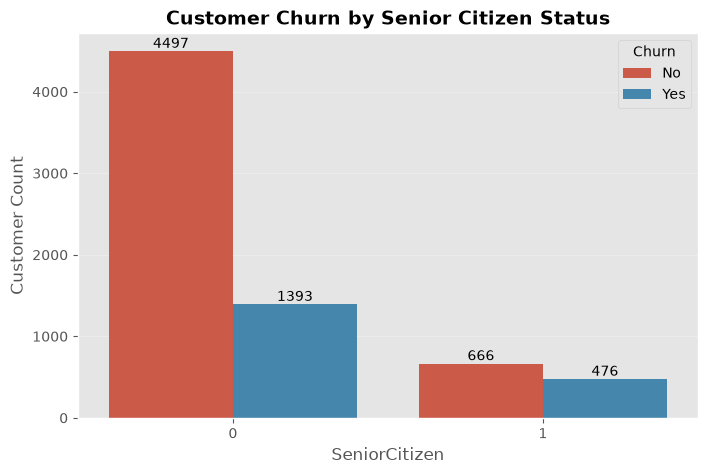

Churn,No,Yes
SeniorCitizen,,
0,76.3,23.7
1,58.3,41.7


In [21]:
plot_churn_by_feature(
    "SeniorCitizen",
    "Customer Churn by Senior Citizen Status"
)

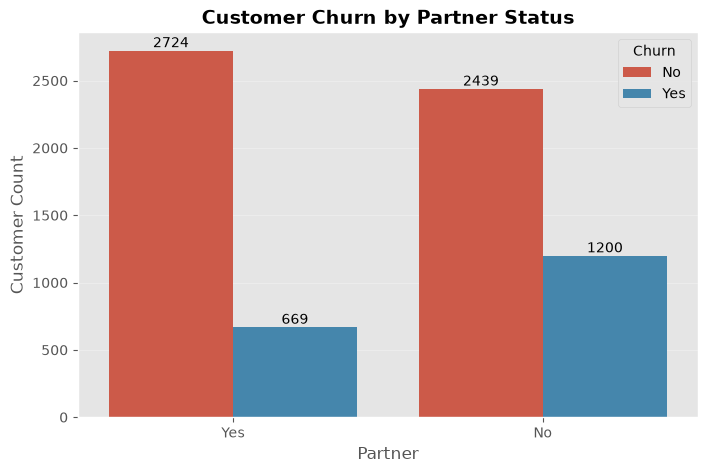

Churn,No,Yes
Partner,,
No,67.0,33.0
Yes,80.3,19.7


In [22]:
plot_churn_by_feature(
    "Partner",
    "Customer Churn by Partner Status"
)

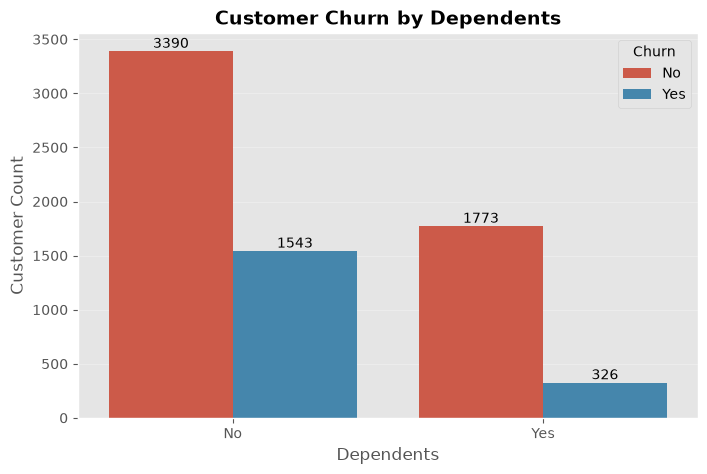

Churn,No,Yes
Dependents,,
No,68.7,31.3
Yes,84.5,15.5


In [23]:
plot_churn_by_feature(
    "Dependents",
    "Customer Churn by Dependents"
)

In [25]:
demographic_summary = pd.DataFrame({

    "Feature":[
        "Gender",
        "Senior Citizen",
        "Partner",
        "Dependents"
    ],

    "Highest Churn Group":[
        "No Significant Difference",
        "Senior Citizens",
        "No Partner",
        "No Dependents"
    ],

    "Churn Rate":[
        "~26%",
        "41.7%",
        "33.0%",
        "31.3%"
    ],

    "Impact":[
        "Low",
        "High",
        "High",
        "High"
    ]

})

demographic_summary

,Feature,Highest Churn Group,Churn Rate,Impact
0,Gender,No Significant Difference,~26%,Low
1,Senior Citizen,Senior Citizens,41.7%,High
2,Partner,No Partner,33.0%,High
3,Dependents,No Dependents,31.3%,High


### Demographic Analysis Summary

The analysis indicates that demographic characteristics such as senior citizen status, partner status, and dependent status are associated with customer churn. Gender, however, does not appear to have a meaningful effect.

# Section 4: Service Analysis

## Business Question

Do the services subscribed by customers influence their likelihood of churning?

This section examines the relationship between customer services and churn behavior.

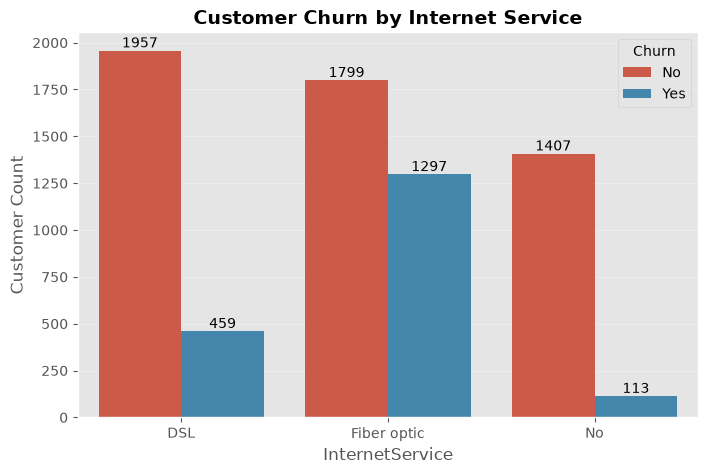

Churn,No,Yes
InternetService,,
DSL,81.0,19.0
Fiber optic,58.1,41.9
No,92.6,7.4


In [26]:
plot_churn_by_feature(
    "InternetService",
    "Customer Churn by Internet Service"
)

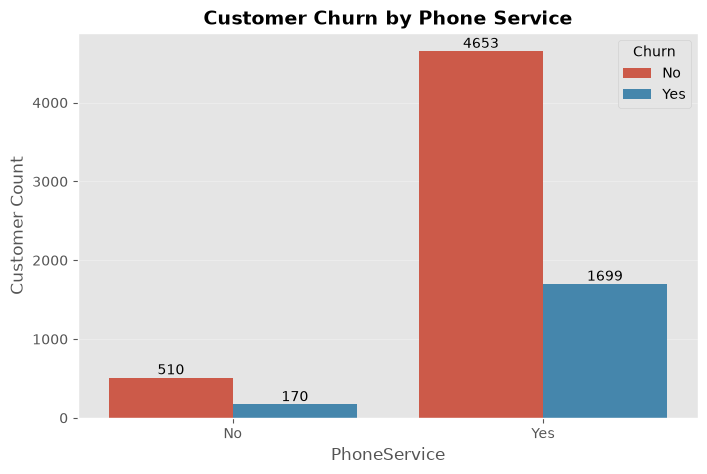

Churn,No,Yes
PhoneService,,
No,75.0,25.0
Yes,73.3,26.7


In [27]:
plot_churn_by_feature(
    "PhoneService",
    "Customer Churn by Phone Service"
)

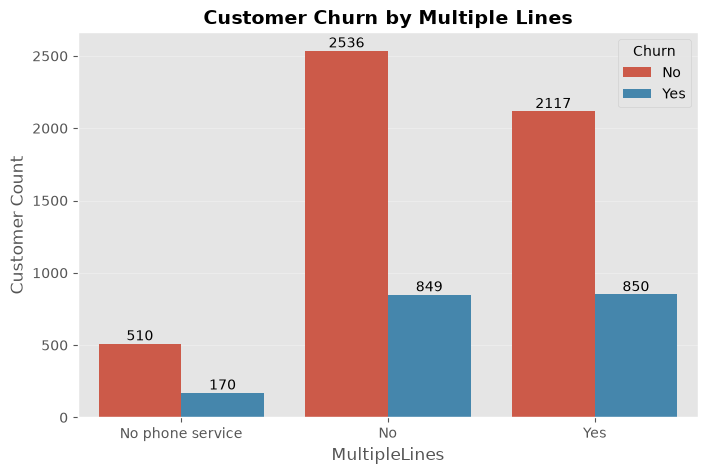

Churn,No,Yes
MultipleLines,,
No,74.9,25.1
No phone service,75.0,25.0
Yes,71.4,28.6


In [28]:
plot_churn_by_feature(
    "MultipleLines",
    "Customer Churn by Multiple Lines"
)

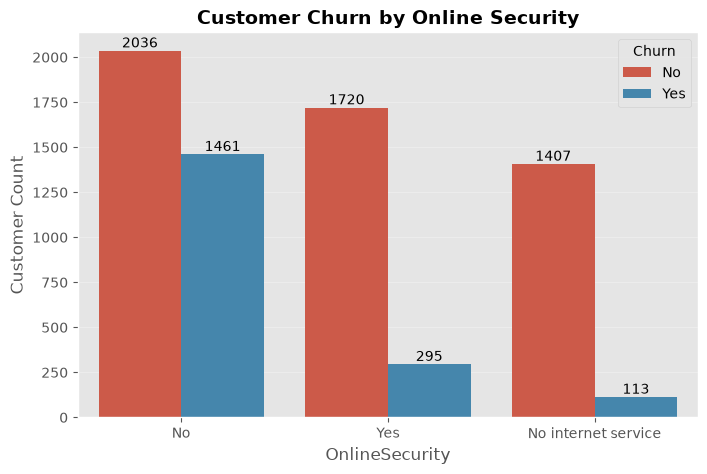

Churn,No,Yes
OnlineSecurity,,
No,58.2,41.8
No internet service,92.6,7.4
Yes,85.4,14.6


In [29]:
plot_churn_by_feature(
    "OnlineSecurity",
    "Customer Churn by Online Security"
)

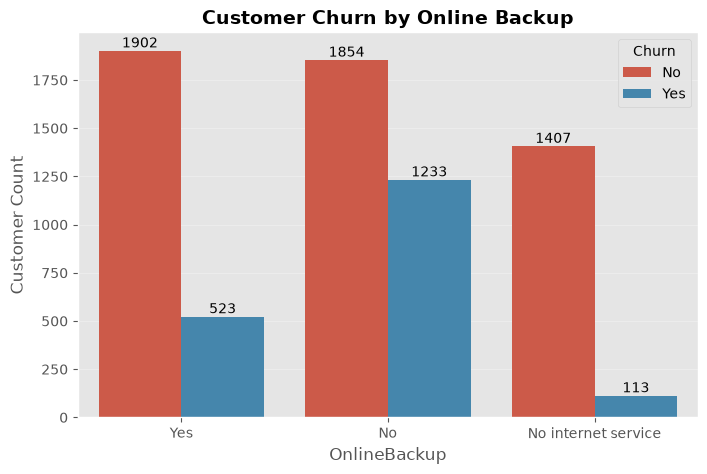

Churn,No,Yes
OnlineBackup,,
No,60.1,39.9
No internet service,92.6,7.4
Yes,78.4,21.6


In [30]:
plot_churn_by_feature(
    "OnlineBackup",
    "Customer Churn by Online Backup"
)

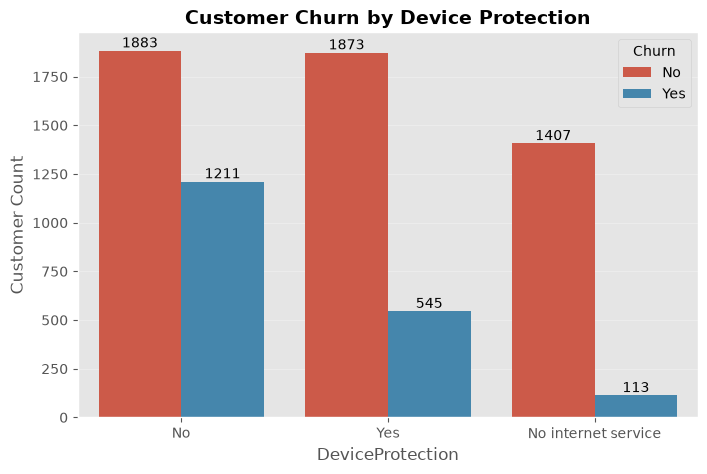

Churn,No,Yes
DeviceProtection,,
No,60.9,39.1
No internet service,92.6,7.4
Yes,77.5,22.5


In [31]:
plot_churn_by_feature(
    "DeviceProtection",
    "Customer Churn by Device Protection"
)

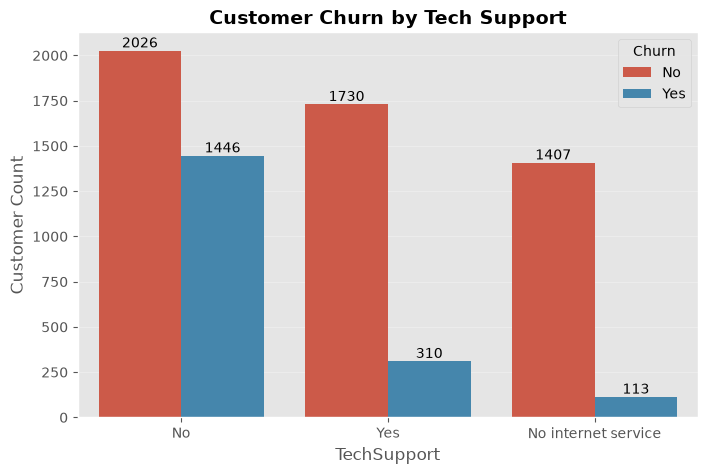

Churn,No,Yes
TechSupport,,
No,58.4,41.6
No internet service,92.6,7.4
Yes,84.8,15.2


In [32]:
plot_churn_by_feature(
    "TechSupport",
    "Customer Churn by Tech Support"
)

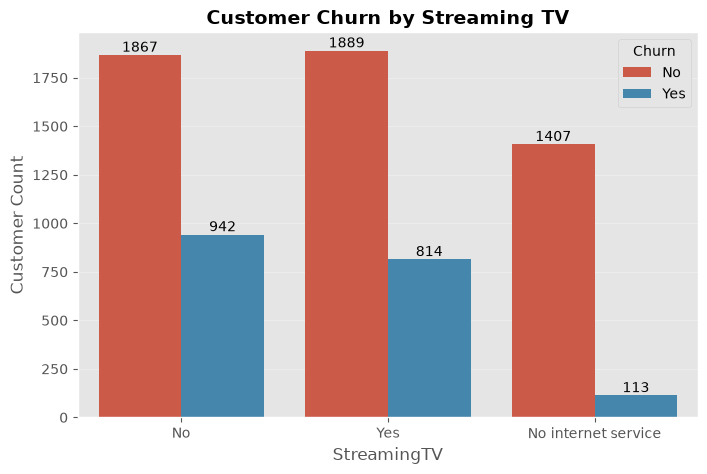

Churn,No,Yes
StreamingTV,,
No,66.5,33.5
No internet service,92.6,7.4
Yes,69.9,30.1


In [33]:
plot_churn_by_feature(
    "StreamingTV",
    "Customer Churn by Streaming TV"
)

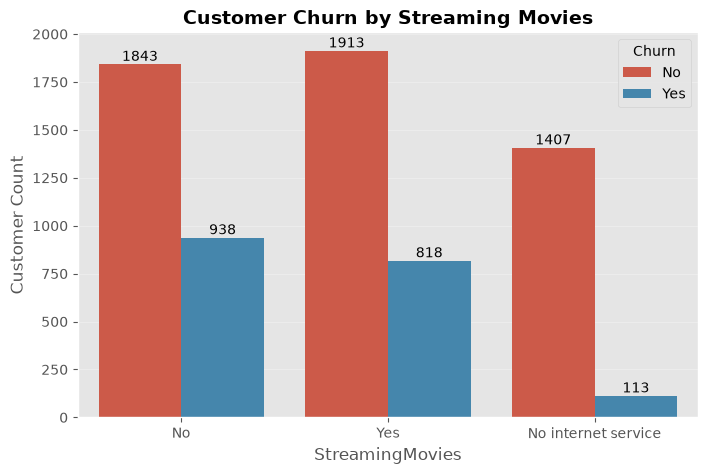

Churn,No,Yes
StreamingMovies,,
No,66.3,33.7
No internet service,92.6,7.4
Yes,70.0,30.0


In [34]:
plot_churn_by_feature(
    "StreamingMovies",
    "Customer Churn by Streaming Movies"
)

## Service Analysis Summary

The analysis of customer services reveals that internet-related services have a much stronger relationship with customer churn than phone-related services.

Key observations include:

- Customers using **Fiber Optic** internet have the highest churn rate among internet service types (**41.9%**).
- Customers **without Online Security** exhibit one of the highest churn rates (**41.8%**), indicating that this service is strongly associated with customer retention.
- Customers **without Online Backup** also experience a noticeably higher churn rate (**39.9%**) compared to those who subscribe to the service.
- Customers **without Device Protection** show a substantially higher churn rate (**39.1%**) than customers who have device protection (**22.5%**).
- Customers **without Tech Support** have the highest churn rate among service-related features (**41.6%**), highlighting technical support as a critical retention factor.
- Streaming TV and Streaming Movies show only a moderate relationship with churn, suggesting they are less influential than security and support services.
- Phone Service and Multiple Lines appear to have only a limited impact on customer churn.

Overall, security, backup, protection, and technical support services appear to play a significant role in customer retention.

In [35]:
service_summary = pd.DataFrame({

    "Feature":[
        "Internet Service",
        "Phone Service",
        "Multiple Lines",
        "Online Security",
        "Online Backup",
        "Device Protection",
        "Tech Support",
        "Streaming TV",
        "Streaming Movies"
    ],

    "Highest Risk Group":[
        "Fiber optic",
        "No Significant Difference",
        "Multiple Lines",
        "No Online Security",
        "No Online Backup",
        "No Device Protection",
        "No Tech Support",
        "No Streaming TV",
        "No Streaming Movies"
    ],

    "Highest Churn Rate":[
        "41.9%",
        "~26%",
        "28.6%",
        "41.8%",
        "39.9%",
        "39.1%",
        "41.6%",
        "33.5%",
        "33.7%"
    ],

    "Impact":[
        "High",
        "Low",
        "Low",
        "High",
        "High",
        "High",
        "High",
        "Medium",
        "Medium"
    ]

})

service_summary

,Feature,Highest Risk Group,Highest Churn Rate,Impact
0,Internet Service,Fiber optic,41.9%,High
1,Phone Service,No Significant Difference,~26%,Low
2,Multiple Lines,Multiple Lines,28.6%,Low
3,Online Security,No Online Security,41.8%,High
4,Online Backup,No Online Backup,39.9%,High
5,Device Protection,No Device Protection,39.1%,High
6,Tech Support,No Tech Support,41.6%,High
7,Streaming TV,No Streaming TV,33.5%,Medium
8,Streaming Movies,No Streaming Movies,33.7%,Medium


# Section 5: Contract & Billing Analysis

## Business Question

How do customer contract types and billing preferences influence churn behavior?

This section analyzes whether different contract types, payment methods, and billing preferences are associated with customer churn.

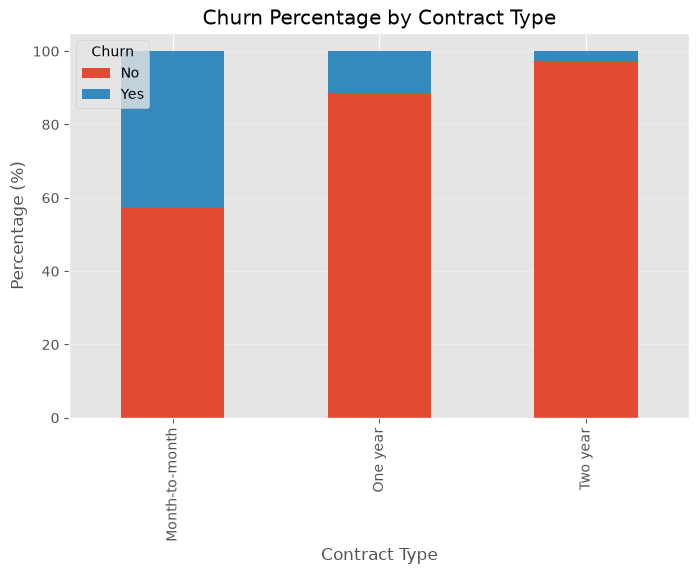

Churn,No,Yes
Contract,,
Month-to-month,57.3,42.7
One year,88.7,11.3
Two year,97.2,2.8


In [36]:
contract_rate = (
    pd.crosstab(
        df["Contract"],
        df["Churn"],
        normalize="index"
    ) * 100
).round(1)

contract_rate.plot(
    kind="bar",
    stacked=True,
    figsize=(8,5)
)

plt.title("Churn Percentage by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Percentage (%)")

plt.legend(title="Churn")

plt.grid(axis="y", alpha=0.3)

plt.show()

display(contract_rate)

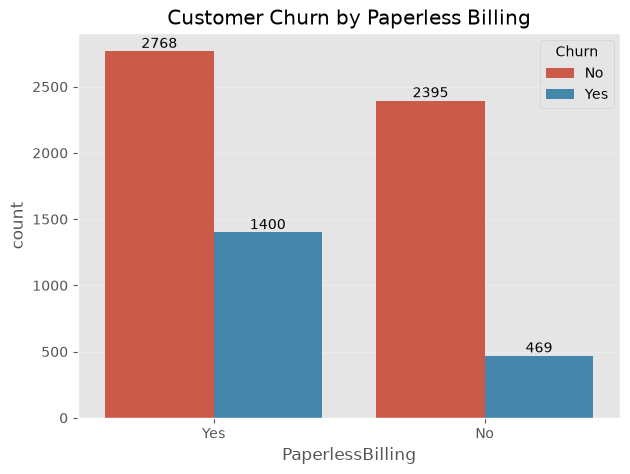

Churn,No,Yes
PaperlessBilling,,
No,83.6,16.4
Yes,66.4,33.6


In [37]:
plt.figure(figsize=(7,5))

ax = sns.countplot(
    data=df,
    x="PaperlessBilling",
    hue="Churn"
)

plt.title("Customer Churn by Paperless Billing")

for container in ax.containers:
    ax.bar_label(container)

plt.grid(axis="y", alpha=0.3)

plt.show()

display(
    (
        pd.crosstab(
            df["PaperlessBilling"],
            df["Churn"],
            normalize="index"
        )*100
    ).round(1)
)

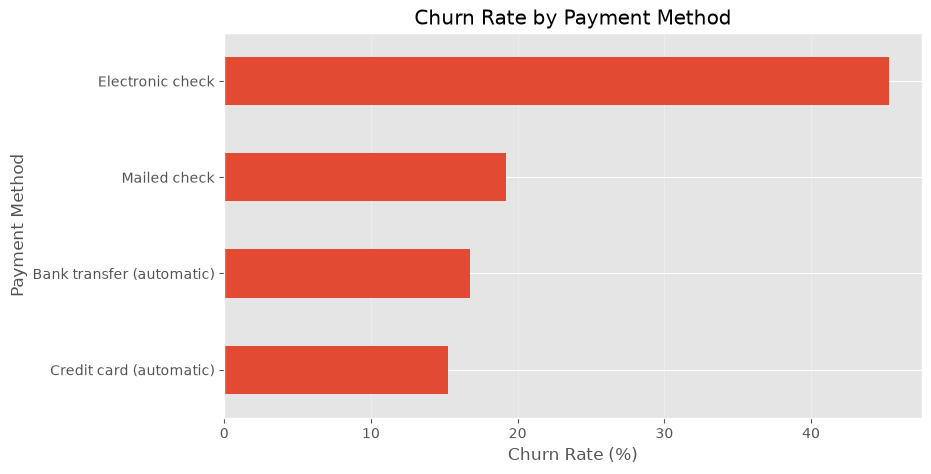

PaymentMethod
Credit card (automatic)      15.3
Bank transfer (automatic)    16.7
Mailed check                 19.2
Electronic check             45.3
Name: Yes, dtype: float64

In [38]:
payment_rate = (
    pd.crosstab(
        df["PaymentMethod"],
        df["Churn"],
        normalize="index"
    )["Yes"] * 100
).sort_values()

plt.figure(figsize=(9,5))

payment_rate.plot(
    kind="barh"
)

plt.title("Churn Rate by Payment Method")
plt.xlabel("Churn Rate (%)")
plt.ylabel("Payment Method")

plt.grid(axis="x", alpha=0.3)

plt.show()

display(payment_rate.round(1))

## Contract & Billing Analysis Summary

Contract and billing characteristics demonstrate the strongest relationship with customer churn observed so far.

Key findings include:

- Customers with **Month-to-Month contracts** have the highest churn rate (**42.7%**), while customers with **Two-Year contracts** have the lowest churn rate (**2.8%**).
- Customers using **Paperless Billing** churn at approximately twice the rate of customers who do not use paperless billing.
- **Electronic Check** users exhibit the highest churn rate (**45.3%**) among all payment methods.
- Customers paying via **Credit Card** or **Automatic Bank Transfer** experience substantially lower churn rates.

These findings indicate that contract duration and payment behavior are among the most influential business factors associated with customer churn.

In [39]:
billing_summary = pd.DataFrame({

    "Feature":[
        "Contract Type",
        "Paperless Billing",
        "Payment Method"
    ],

    "Highest Risk Group":[
        "Month-to-Month",
        "Paperless Billing = Yes",
        "Electronic Check"
    ],

    "Highest Churn Rate":[
        "42.7%",
        "33.6%",
        "45.3%"
    ],

    "Impact":[
        "Very High",
        "High",
        "Very High"
    ]

})

billing_summary

,Feature,Highest Risk Group,Highest Churn Rate,Impact
0,Contract Type,Month-to-Month,42.7%,Very High
1,Paperless Billing,Paperless Billing = Yes,33.6%,High
2,Payment Method,Electronic Check,45.3%,Very High


# Section 6: Financial Analysis

## Business Question

Do customer tenure and charges influence the likelihood of churn?

This section investigates whether customer lifetime, monthly charges, and total charges are associated with customer churn.

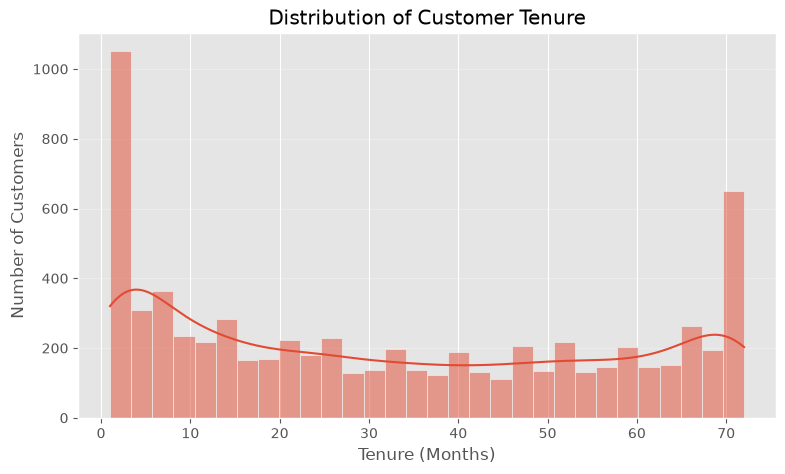

In [40]:
plt.figure(figsize=(9,5))

sns.histplot(
    data=df,
    x="tenure",
    bins=30,
    kde=True
)

plt.title("Distribution of Customer Tenure")
plt.xlabel("Tenure (Months)")
plt.ylabel("Number of Customers")

plt.grid(axis="y", alpha=0.3)

plt.show()

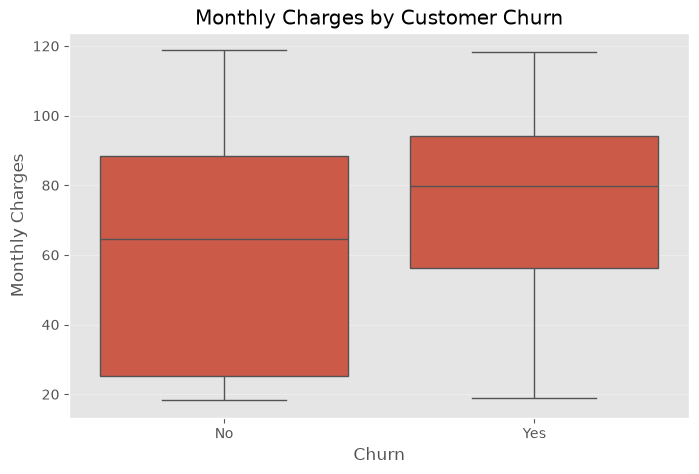

In [41]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Churn",
    y="MonthlyCharges"
)

plt.title("Monthly Charges by Customer Churn")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")

plt.grid(axis="y", alpha=0.3)

plt.show()

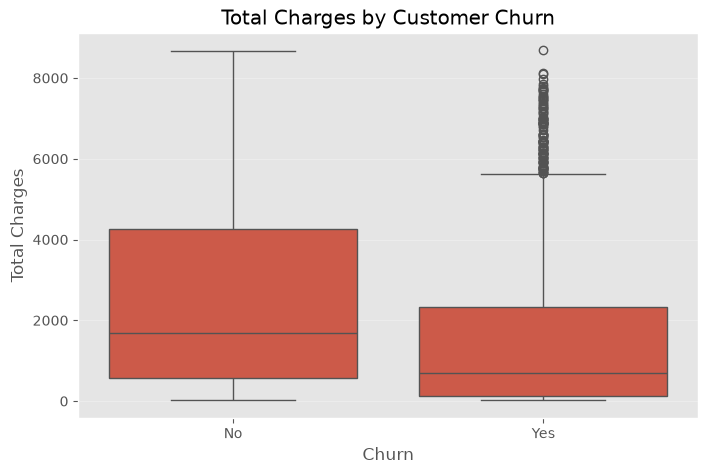

In [42]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Churn",
    y="TotalCharges"
)

plt.title("Total Charges by Customer Churn")
plt.xlabel("Churn")
plt.ylabel("Total Charges")

plt.grid(axis="y", alpha=0.3)

plt.show()

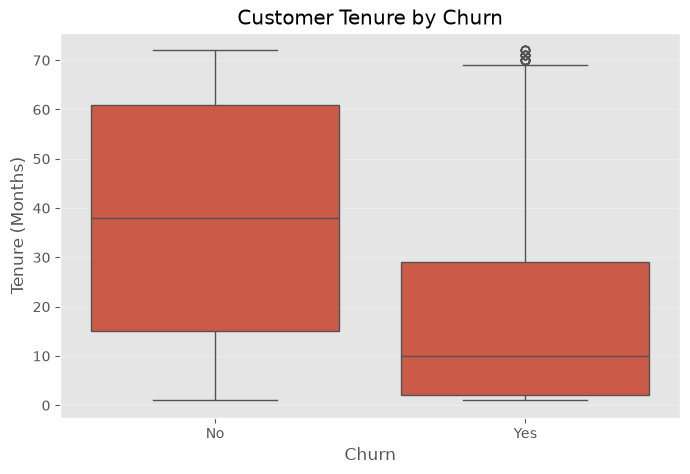

In [43]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Churn",
    y="tenure"
)

plt.title("Customer Tenure by Churn")
plt.xlabel("Churn")
plt.ylabel("Tenure (Months)")

plt.grid(axis="y", alpha=0.3)

plt.show()

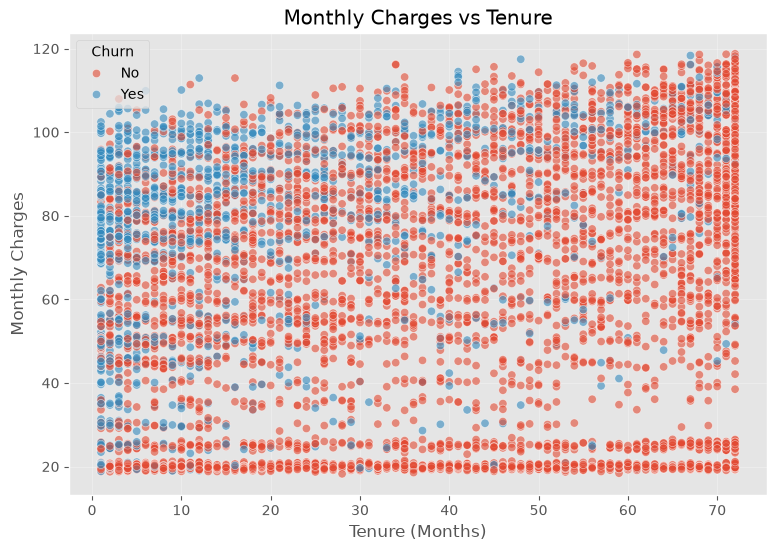

In [44]:
plt.figure(figsize=(9,6))

sns.scatterplot(
    data=df,
    x="tenure",
    y="MonthlyCharges",
    hue="Churn",
    alpha=0.6
)

plt.title("Monthly Charges vs Tenure")
plt.xlabel("Tenure (Months)")
plt.ylabel("Monthly Charges")

plt.grid(alpha=0.3)

plt.show()

## Financial Analysis Summary

The financial analysis reveals a strong relationship between customer tenure, monthly charges, and churn behavior.

Key findings include:

- Customers who churn generally have **higher monthly charges** than customers who remain with the company.
- Customers who remain with the company tend to accumulate **higher total charges**, reflecting their longer relationship with the company.
- Customer tenure is one of the strongest indicators of churn, with churned customers typically having much shorter subscription periods.
- The tenure distribution indicates that many customers either leave during the early stages of their subscription or remain loyal for a long period.

Overall, customer tenure and monthly charges appear to be important factors associated with customer churn and should be considered during predictive modeling.

In [45]:
financial_summary = pd.DataFrame({

    "Feature":[
        "Customer Tenure",
        "Monthly Charges",
        "Total Charges"
    ],

    "Observation":[
        "Short tenure customers churn more",
        "Higher monthly charges are associated with higher churn",
        "Long-term customers accumulate higher total charges"
    ],

    "Impact":[
        "Very High",
        "High",
        "Medium"
    ]

})

financial_summary

,Feature,Observation,Impact
0,Customer Tenure,Short tenure customers churn more,Very High
1,Monthly Charges,Higher monthly charges are associated with hig...,High
2,Total Charges,Long-term customers accumulate higher total ch...,Medium


# Section 7: Correlation Analysis

## Business Question

Is there a relationship between the numerical variables in the dataset?

This section explores the correlations among numerical features to identify potential relationships that may support customer churn analysis.

In [46]:
numeric_df = df.select_dtypes(include=["int64", "float64"])

numeric_df.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
0,0,1,29.85,29.85
1,0,34,56.95,1889.50
2,0,2,53.85,108.15
3,0,45,42.30,1840.75
4,0,2,70.70,151.65


In [47]:
correlation = numeric_df.corr()

correlation

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
SeniorCitizen,1.000000,0.015683,0.219874,0.102411
tenure,0.015683,1.000000,0.246862,0.825880
MonthlyCharges,0.219874,0.246862,1.000000,0.651065
TotalCharges,0.102411,0.825880,0.651065,1.000000


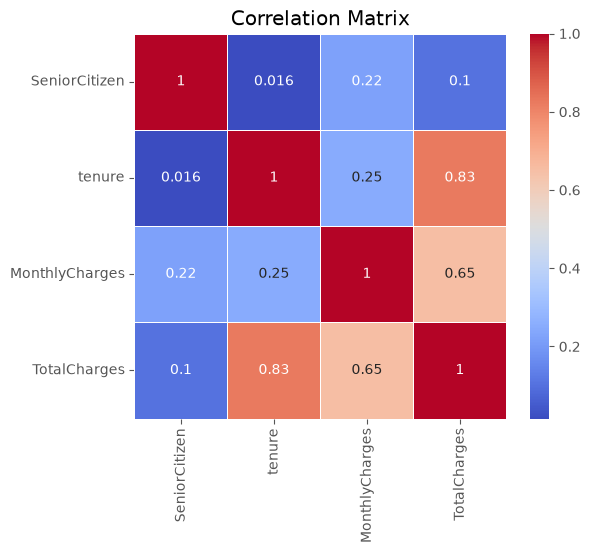

In [48]:
plt.figure(figsize=(6,5))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Matrix")

plt.show()

## Correlation Analysis Summary

The correlation analysis highlights the relationships among the numerical variables in the dataset.

Key observations include:

- **Tenure** has a strong positive correlation with **Total Charges** (**0.83**), indicating that customers who remain with the company longer naturally accumulate higher total charges.
- **Monthly Charges** show a moderate positive correlation with **Total Charges** (**0.65**), suggesting that customers paying higher monthly fees tend to accumulate larger overall payments.
- **Senior Citizen** exhibits only weak correlations with the remaining numerical variables, indicating that its influence is largely independent of customer tenure and charges.
- No strong multicollinearity is observed among the predictor variables except for the expected relationship between tenure and total charges.

Overall, the numerical variables appear suitable for predictive modeling without significant correlation-related concerns.

In [49]:
correlation_summary = pd.DataFrame({

    "Variable Pair":[
        "Tenure ↔ TotalCharges",
        "MonthlyCharges ↔ TotalCharges",
        "SeniorCitizen ↔ MonthlyCharges",
        "SeniorCitizen ↔ Tenure"
    ],

    "Correlation":[
        0.83,
        0.65,
        0.22,
        0.02
    ],

    "Strength":[
        "Strong",
        "Moderate",
        "Weak",
        "Very Weak"
    ]

})

correlation_summary

,Variable Pair,Correlation,Strength
0,Tenure ↔ TotalCharges,0.83,Strong
1,MonthlyCharges ↔ TotalCharges,0.65,Moderate
2,SeniorCitizen ↔ MonthlyCharges,0.22,Weak
3,SeniorCitizen ↔ Tenure,0.02,Very Weak


# Executive Summary

The exploratory data analysis identified several business factors strongly associated with customer churn.

### Key Findings

- Approximately **26.6%** of customers have churned, indicating a moderate class imbalance.
- Customer demographics reveal that **Senior Citizens** experience substantially higher churn rates, while gender has minimal impact.
- Internet-related services play an important role in customer retention. Customers without **Online Security**, **Tech Support**, **Online Backup**, or **Device Protection** exhibit considerably higher churn rates.
- Customers using **Fiber Optic Internet** experience one of the highest churn rates among service categories.
- Contract type is the strongest business indicator of churn. Customers with **Month-to-Month contracts** are significantly more likely to churn than customers with longer contracts.
- Customers using **Electronic Check** as their payment method exhibit the highest churn rate among all payment options.
- Financial analysis indicates that churned customers generally have **shorter tenures** and **higher monthly charges**, while retained customers accumulate larger total charges over time.

### Business Implications

The findings suggest that customer retention strategies should prioritize:

- Customers with Month-to-Month contracts.
- Customers using Electronic Check payments.
- Senior Citizens.
- Customers without Online Security or Tech Support.
- Customers with high Monthly Charges and short Tenure.

These insights will guide the feature selection process and support the development of accurate machine learning models for customer churn prediction.

# EDA Conclusion

The exploratory data analysis successfully identified the major characteristics associated with customer churn.

The dataset has been fully explored through descriptive statistics, visual analysis, business-oriented insights, and correlation analysis.

The cleaned dataset is now ready for feature engineering, data encoding, model training, and predictive analysis.